# SentinelMail — Data Exploration: ai4privacy/pii-masking-300k

Exploratory analysis of the primary training dataset before any model training.
Label mapping and privacy rules follow `.claude/rules/datasets.md`.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

REPO_ROOT = Path("..").resolve()
DATA_RAW = REPO_ROOT / "data" / "ai4privacy" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "ai4privacy" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))
from data.preprocessing import (
    parse_mask, build_labels, LABEL_COLS,
    FINANCIAL_ENTITY_TYPES, CONFIDENTIAL_ENTITY_TYPES,
)

/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download Dataset

In [2]:
ds = load_dataset("ai4privacy/pii-masking-300k", cache_dir=str(DATA_RAW))
print(ds)

DatasetDict({
    train: Dataset({
        features: ['source_text', 'target_text', 'privacy_mask', 'span_labels', 'mbert_text_tokens', 'mbert_bio_labels', 'id', 'language', 'set'],
        num_rows: 177677
    })
    validation: Dataset({
        features: ['source_text', 'target_text', 'privacy_mask', 'span_labels', 'mbert_text_tokens', 'mbert_bio_labels', 'id', 'language', 'set'],
        num_rows: 47728
    })
})


## 2. Dataset Overview

In [3]:
print("Splits:", list(ds.keys()))
for split, dataset in ds.items():
    print(f"  {split}: {len(dataset):,} rows | columns: {dataset.column_names}")

# Show one sample — truncate source_text to 50 chars per privacy rule
sample = ds["train"][0]
sample_display = {k: (v[:50] + "\u2026" if k == "source_text" and isinstance(v, str) else v)
                  for k, v in sample.items()}
print("\nSample row (source_text truncated to 50 chars):")
for k, v in sample_display.items():
    print(f"  {k}: {v}")

Splits: ['train', 'validation']
  train: 177,677 rows | columns: ['source_text', 'target_text', 'privacy_mask', 'span_labels', 'mbert_text_tokens', 'mbert_bio_labels', 'id', 'language', 'set']
  validation: 47,728 rows | columns: ['source_text', 'target_text', 'privacy_mask', 'span_labels', 'mbert_text_tokens', 'mbert_bio_labels', 'id', 'language', 'set']

Sample row (source_text truncated to 50 chars):
  source_text: Subject: Group Messaging for Admissions Process

G…
  target_text: Subject: Group Messaging for Admissions Process

Good morning, everyone,

I hope this message finds you well. As we continue our admissions processes, I would like to update you on the latest developments and key information. Please find below the timeline for our upcoming meetings:

- [USERNAME] - Meeting at [TIME]
- [USERNAME] - Meeting at [TIME]
- [USERNAME] - Meeting at [TIME]
- [USERNAME] - Meeting at [TIME]
- [USERNAME] 
  privacy_mask: [{'value': 'wynqvrh053', 'start': 287, 'end': 297, 'label': 'USE

## 3. Filter to English

In [4]:
# Dataset uses full names ("English"), not ISO codes ("en")
ds_en = ds.filter(lambda x: x["language"] == "English")

print("Rows kept after English filter:")
for split in ds_en:
    orig = len(ds[split])
    kept = len(ds_en[split])
    print(f"  {split}: {kept:,} / {orig:,} ({100*kept/orig:.1f}%)")

Rows kept after English filter:
  train: 29,908 / 177,677 (16.8%)
  validation: 7,946 / 47,728 (16.6%)


## 4. Column Schema

In [5]:
train_df = ds_en["train"].to_pandas()

print("Column dtypes:")
print(train_df.dtypes)
print("\nNull counts:")
print(train_df.isnull().sum())

# Debug: show actual type/value of privacy_mask before filtering
print("\nprivacy_mask — first 3 raw values:")
for i, v in enumerate(train_df["privacy_mask"].head(3)):
    print(f"  [{i}] type={type(v).__name__}  value={repr(v)[:120]}")

def _has_entities(x):
    if x is None:
        return False
    if isinstance(x, float):  # catches pandas NA / NaN
        return False
    # HuggingFace → pandas often yields numpy.ndarray, not list
    if isinstance(x, (list, np.ndarray)):
        return len(x) > 0
    if isinstance(x, str):
        try:
            return len(json.loads(x)) > 0
        except (json.JSONDecodeError, TypeError):
            return False
    return False

mask_rows = train_df[train_df["privacy_mask"].apply(_has_entities)]
print(f"\nRows with non-empty privacy_mask: {len(mask_rows):,}")

if len(mask_rows) > 0:
    mask_val = mask_rows.iloc[0]["privacy_mask"]
    if isinstance(mask_val, str):
        mask_val = json.loads(mask_val)
    print("\nprivacy_mask schema example:")
    print(json.dumps(mask_val[:2], indent=2, default=str))
else:
    print("\nWARNING: no non-empty privacy_mask rows found — check column name/format above.")

Column dtypes:
source_text             str
target_text             str
privacy_mask         object
span_labels             str
mbert_text_tokens    object
mbert_bio_labels     object
id                      str
language                str
set                     str
dtype: object

Null counts:
source_text          0
target_text          0
privacy_mask         0
span_labels          0
mbert_text_tokens    0
mbert_bio_labels     0
id                   0
language             0
set                  0
dtype: int64

privacy_mask — first 3 raw values:
  [0] type=ndarray  value=array([{'value': 'wynqvrh053', 'start': 287, 'end': 297, 'label': 'USERNAME'},
       {'value': '10:20am', 'start': 311,
  [1] type=ndarray  value=array([{'value': '2:33 PM', 'start': 13, 'end': 20, 'label': 'TIME'},
       {'value': 'N23', 'start': 23, 'end': 26, 'l
  [2] type=ndarray  value=array([{'value': '5:24am', 'start': 263, 'end': 269, 'label': 'TIME'},
       {'value': 'August 5th, 2057', 'start': 273

Rows wi

## 5. PII Entity Class Distribution

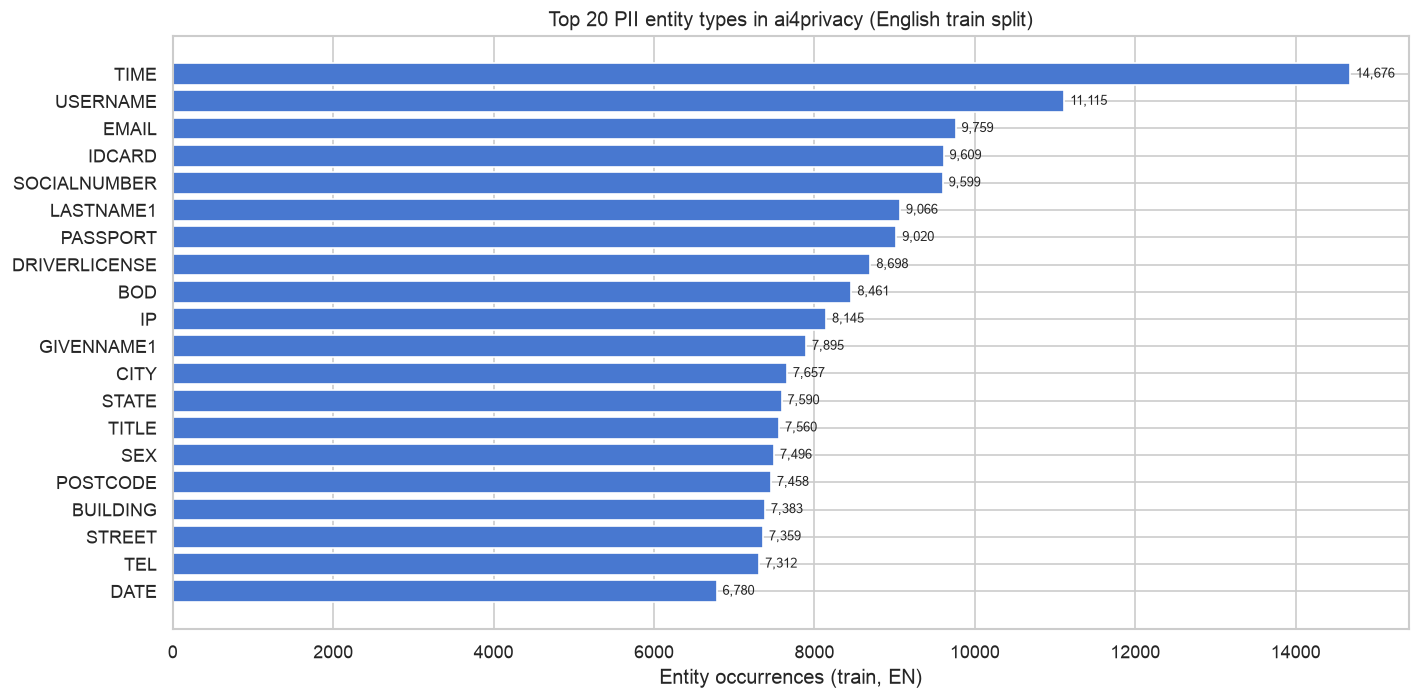


Total entity types in dataset: 28
Total entity occurrences: 193,086


In [6]:
entity_counts = Counter()
for mask in train_df["privacy_mask"]:
    for ent in parse_mask(mask):
        entity_counts[ent["label"]] += 1

if not entity_counts:
    print("No entities found — check privacy_mask format in cell 4 output.")
else:
    top20 = entity_counts.most_common(20)
    labels_top, counts_top = zip(*top20)

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(labels_top[::-1], counts_top[::-1])
    ax.set_xlabel("Entity occurrences (train, EN)")
    ax.set_title("Top 20 PII entity types in ai4privacy (English train split)")
    for bar, count in zip(bars, counts_top[::-1]):
        ax.text(bar.get_width() + max(counts_top) * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{count:,}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"\nTotal entity types in dataset: {len(entity_counts)}")
    print(f"Total entity occurrences: {sum(entity_counts.values()):,}")

## 6. Sensitive Category Subsets (Financial & Confidential)

In [7]:
def has_financial(mask):
    return any(e["label"] in FINANCIAL_ENTITY_TYPES for e in parse_mask(mask))

if len(train_df) == 0:
    raise ValueError(
        "train_df is empty — re-run the English filter cell "
        '(language must be "English", not "en").'
    )

fin_mask = train_df["privacy_mask"].apply(has_financial)
n_fin = fin_mask.sum()
print(f"Rows with ≥1 financial entity: {n_fin:,} ({100*n_fin/len(train_df):.1f}% of EN train)")

fin_entity_counts = Counter(
    e["label"]
    for mask in train_df["privacy_mask"]
    for e in parse_mask(mask)
    if e["label"] in FINANCIAL_ENTITY_TYPES
)
print("\nFinancial entity distribution:")
for label, cnt in fin_entity_counts.most_common():
    print(f"  {label}: {cnt:,}")

def has_confidential(mask):
    return any(e["label"] in CONFIDENTIAL_ENTITY_TYPES for e in parse_mask(mask))

conf_mask = train_df["privacy_mask"].apply(has_confidential)
n_conf = conf_mask.sum()
print(f"\nRows with ≥1 confidential entity: {n_conf:,} ({100*n_conf/len(train_df):.1f}% of EN train)")

conf_entity_counts = Counter(
    e["label"]
    for mask in train_df["privacy_mask"]
    for e in parse_mask(mask)
    if e["label"] in CONFIDENTIAL_ENTITY_TYPES
)
print("\nConfidential entity distribution:")
for label, cnt in conf_entity_counts.most_common():
    print(f"  {label}: {cnt:,}")

Rows with ≥1 financial entity: 5,688 (19.0% of EN train)

Financial entity distribution:
  SOCIALNUMBER: 9,599
  CARDISSUER: 5

Rows with ≥1 confidential entity: 13,252 (44.3% of EN train)

Confidential entity distribution:
  IDCARD: 9,609
  PASSPORT: 9,020
  DRIVERLICENSE: 8,698
  PASS: 5,637


## 7. Label Mapping (Project Schema)

Label distribution (train, EN):
benign           3482
PII             26426
financial        5688
confidential    13252


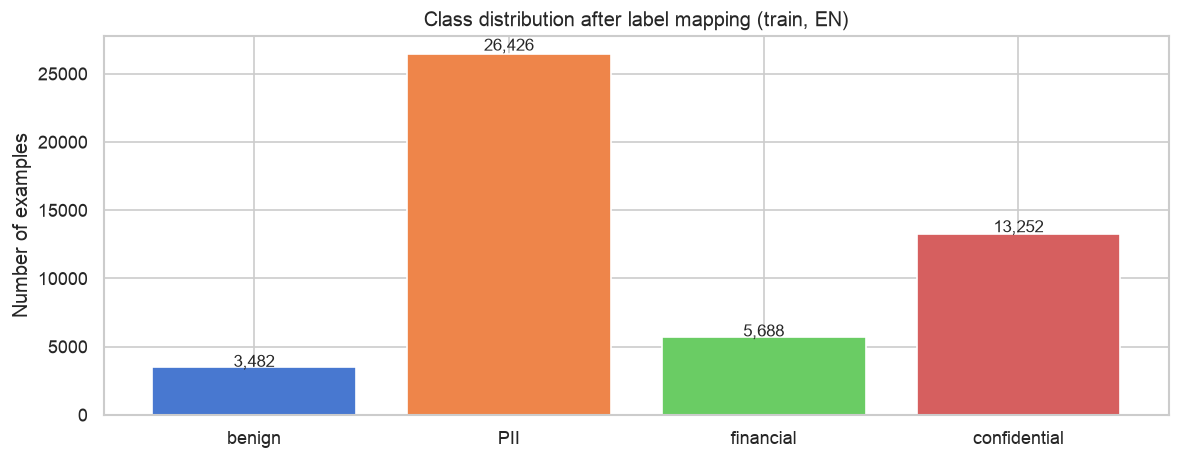


Label co-occurrence matrix:
              benign    PII  financial  confidential
benign          3482      0          0             0
PII                0  26426       5688         13252
financial          0   5688       5688          3645
confidential       0  13252       3645         13252


In [8]:
label_df = train_df["privacy_mask"].apply(build_labels).apply(pd.Series)
train_df = pd.concat([train_df, label_df], axis=1)

print("Label distribution (train, EN):")
print(label_df[LABEL_COLS].sum().to_string())

fig, ax = plt.subplots(figsize=(10, 4))
counts = label_df[LABEL_COLS].sum()
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("muted", len(LABEL_COLS)))
ax.set_ylabel("Number of examples")
ax.set_title("Class distribution after label mapping (train, EN)")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print("\nLabel co-occurrence matrix:")
co = label_df[LABEL_COLS].T.dot(label_df[LABEL_COLS])
print(co)

## 8. Text Length Distribution

Examples exceeding 512 tokens: 0 (0.0%)
count    29908.000000
mean       126.883677
std         35.329138
min         13.000000
25%        101.000000
50%        121.000000
75%        147.000000
max        391.000000
Name: token_count, dtype: float64


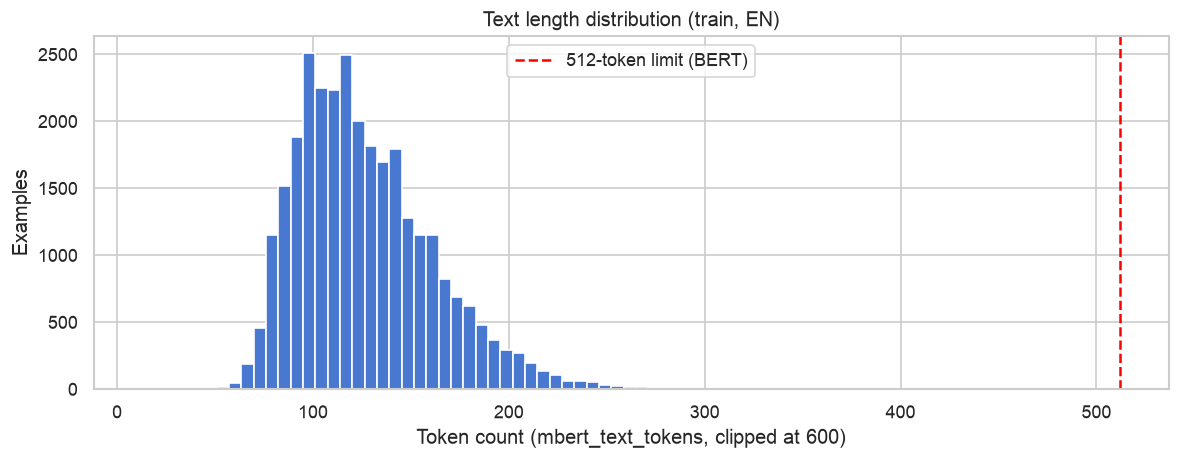

In [9]:
train_df["token_count"] = train_df["mbert_text_tokens"].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else len(json.loads(x))
)

over_512 = (train_df["token_count"] > 512).sum()
print(f"Examples exceeding 512 tokens: {over_512:,} ({100*over_512/len(train_df):.1f}%)")
print(train_df["token_count"].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df["token_count"].clip(upper=600), bins=60, edgecolor="white")
ax.axvline(512, color="red", linestyle="--", linewidth=1.5, label="512-token limit (BERT)")
ax.set_xlabel("Token count (mbert_text_tokens, clipped at 600)")
ax.set_ylabel("Examples")
ax.set_title("Text length distribution (train, EN)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Entity Count per Example

Entity count distribution:
num_entities
0     3482
1     1901
2     2818
3     2515
4     2415
5     1958
6     2171
7     1880
8     1863
9     1605
10    1412
11    1059
12    1001
13     821
14     642


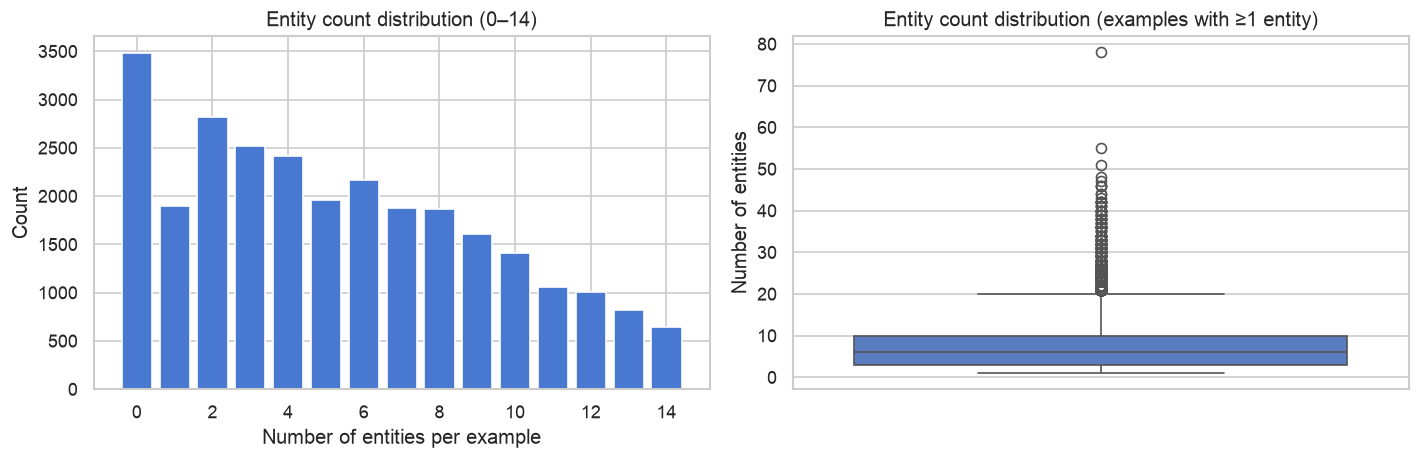

In [10]:
train_df["num_entities"] = train_df["privacy_mask"].apply(lambda m: len(parse_mask(m)))

print("Entity count distribution:")
print(train_df["num_entities"].value_counts().sort_index().head(15).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = train_df["num_entities"].value_counts().sort_index()
axes[0].bar(vc.index[:15], vc.values[:15])
axes[0].set_xlabel("Number of entities per example")
axes[0].set_ylabel("Count")
axes[0].set_title("Entity count distribution (0\u201314)")

sns.boxplot(data=train_df[train_df["num_entities"] > 0], y="num_entities", ax=axes[1])
axes[1].set_title("Entity count distribution (examples with \u22651 entity)")
axes[1].set_ylabel("Number of entities")

plt.tight_layout()
plt.show()

## 10. Sample Inspection

In [11]:
def show_samples(df, label_col, n=5):
    subset = df[df[label_col] == 1].head(n)
    for _, row in subset.iterrows():
        entities = [(e["label"], e["value"][:20]) for e in parse_mask(row["privacy_mask"])]
        print(f"  text[:50]: {row['source_text'][:50]}…")
        print(f"  entities : {entities}")
        print()

print("=== PII-only examples ===")
show_samples(train_df[train_df["financial"] == 0], "PII")

print("=== Financial examples ===")
show_samples(train_df, "financial")

print("=== Confidential examples ===")
show_samples(train_df, "confidential")

print("=== Benign examples ===")
show_samples(train_df, "benign")

=== PII-only examples ===
  text[:50]: Subject: Group Messaging for Admissions Process

G…
  entities : [('USERNAME', 'wynqvrh053'), ('TIME', '10:20am'), ('USERNAME', 'luka.burg'), ('TIME', '21'), ('USERNAME', 'qahil.wittauer'), ('TIME', 'quarter past 13'), ('USERNAME', 'gholamhossein.ruschk'), ('TIME', '9:47 PM'), ('USERNAME', 'pdmjrsyoz1460')]

  text[:50]: - Meeting at 2:33 PM
- N23 - Meeting at 11:29pm
- …
  entities : [('TIME', '2:33 PM'), ('USERNAME', 'N23'), ('TIME', '11:29pm'), ('USERNAME', 'wennmann27'), ('TIME', '4:45 PM')]

  text[:50]: N, WA14 5RW\n   Password: r]iD1#8\n\n...and so on …
  entities : [('PASS', 'r]iD1#8'), ('DATE', 'August 5th, 2057')]

  text[:50]: Subject: Admission Application Attachments Confirm…
  entities : [('PASSPORT', '301025226')]

  text[:50]: s carefully and inform us immediately if there are…
  entities : [('STREET', 'Rue des Écoles'), ('TIME', '13'), ('DATE', 'September/54')]

=== Financial examples ===
  text[:50]: Subject: Admission Notificati

## 11. Save Processed Label File

In [12]:
# Save labels + metadata only — no source_text to avoid storing PII-like content
out_cols = ["token_count", "num_entities", "PII", "financial", "benign", "confidential"]
out_df = train_df[out_cols].reset_index(names="idx")

out_path = DATA_PROCESSED / "labels_en.parquet"
out_df.to_parquet(out_path, index=False)
print(f"Saved {len(out_df):,} rows to {out_path}")
print(out_df.head())

Saved 29,908 rows to /Users/erelv/projects-chkp/final-project/data/ai4privacy/processed/labels_en.parquet
   idx  token_count  num_entities  PII  financial  benign  confidential
0    0          121             9    1          0       0             0
1    1          102             5    1          0       0             0
2    2          132             6    1          1       0             0
3    3          155            18    1          1       0             1
4    4          118             2    1          0       0             1
